# RQ2 — Spatial Distribution of Housing Equity in Southwark

**Research Question:** What is the spatial distribution of housing equity across Southwark LSOAs?

**Maps produced:**
1. **HEI map** — full Housing Equity Index (PCA-weighted composite)
2. **HCI map** — Housing Condition Index (EPC quality + overcrowding sub-index)
3. **Affordability map** — median house price (relative affordability)

**Shapefile key:** `lsoa21cd` from `LSOA_Shapfile/Southwark.shp`

## 0. Setup

In [13]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams.update({'figure.dpi': 130, 'font.family': 'sans-serif', 'axes.spines.top': False, 'axes.spines.right': False})

BASE    = os.path.dirname(os.path.abspath('__file__'))
DATA    = os.path.join(BASE, 'data')
SHP_DIR = os.path.join(BASE, 'LSOA_Shapfile')

print('Setup complete.')

Setup complete.


## 1. Load Data

In [14]:
master = pd.read_csv(os.path.join(DATA, 'master_southwark_hei.csv'))
print(f'Loaded: {master.shape}, unique lsoa21cd: {master["lsoa21cd"].nunique()}')

# Part 1 join produced duplicated lsoa21cd rows — deduplicate to LSOA level
master = master.drop_duplicates(subset=['lsoa21cd']).reset_index(drop=True)
print(f'After dedup: {master.shape}')
print('Columns:', list(master.columns))

Loaded: (3216, 31), unique lsoa21cd: 173
After dedup: (173, 31)
Columns: ['lsoa11cd', 'lsoa21cd', 'lsoa21nm', 'n_properties', 'avg_epc_score', 'avg_epc_rating_num', 'pct_epc_ABC', 'avg_floor_area', 'avg_rooms', 'overcrowding_idx', 'median_house_price', 'transport_ptai', 'ptal_grade', 'ptai_high', 'ptai_low', 'hospital', 'GP', 'pharmacy', 'hospital_rnk', 'hospital_pct', 'domain_h', 'ahah', 'overcrowding_proxy', 'avg_epc_rating_num_al', 'overcrowding_proxy_al', 'median_house_price_al', 'transport_ptai_al', 'hospital_al', 'HEI_equal', 'HEI_pca', 'HEI_quintile']


In [15]:
# Southwark shapefile (lsoa21cd as join key)
gdf = gpd.read_file(os.path.join(SHP_DIR, 'Southwark.shp')).to_crs(epsg=27700)
print(f'Shapefile: {gdf.shape}  — CRS: {gdf.crs}')
print('Columns:', list(gdf.columns))

# Drop columns from master that already exist in shapefile to avoid _x/_y suffixes
shp_extra = set(gdf.columns) - {'geometry', 'lsoa21cd'}
master_merge = master.drop(columns=[c for c in shp_extra if c in master.columns],
                            errors='ignore')

# Merge master → geometry on lsoa21cd
geo = gdf.merge(master_merge, on='lsoa21cd', how='left')
print(f'Merged GeoDataFrame: {geo.shape}  (expect ~166 rows)')
print(f'Missing HEI_bayes: {geo["HEI_bayes"].isnull().sum()}')

Shapefile: (173, 7)  — CRS: EPSG:27700
Columns: ['lsoa21cd', 'lsoa21nm', 'msoa21cd', 'msoa21nm', 'lad22cd', 'lad22nm', 'geometry']
Merged GeoDataFrame: (173, 36)  (expect ~166 rows)
Missing HEI_pca: 0


In [16]:
hci_df = master[['lsoa11cd','lsoa21cd','lsoa21nm',
                  'avg_epc_rating_num','overcrowding_proxy']].copy()

# Winsorise
for col in ['avg_epc_rating_num','overcrowding_proxy']:
    lo, hi = hci_df[col].quantile([0.01, 0.99])
    hci_df[col] = hci_df[col].clip(lo, hi)

# MinMax
scaler = MinMaxScaler()
hci_df[['epc_mm','over_mm']] = scaler.fit_transform(
    hci_df[['avg_epc_rating_num','overcrowding_proxy']]
)

# Direction: invert EPC (higher rating = better → 1-x = worse direction)
hci_df['epc_al']  = 1 - hci_df['epc_mm']
hci_df['over_al'] = hci_df['over_mm']

# HCI = equal-weighted composite
hci_df['HCI'] = hci_df[['epc_al','over_al']].mean(axis=1)

# Quintile
hci_df['HCI_quintile'] = pd.qcut(
    hci_df['HCI'], q=5,
    labels=['Q1 (best condition)','Q2','Q3','Q4','Q5 (worst condition)']
)

print('HCI summary:')
print(hci_df['HCI'].describe().round(3))
print('\nQuintile counts:')
print(hci_df['HCI_quintile'].value_counts().sort_index())

HCI summary:
count   173.000
mean      0.493
std       0.087
min       0.249
25%       0.433
50%       0.491
75%       0.543
max       0.818
Name: HCI, dtype: float64

Quintile counts:
HCI_quintile
Q1 (best condition)     35
Q2                      34
Q3                      35
Q4                      34
Q5 (worst condition)    35
Name: count, dtype: int64


In [17]:
# Affordability: MinMax-normalised median house price
# Higher = more expensive = less affordable
aff_df = master[['lsoa11cd','lsoa21cd','lsoa21nm','median_house_price']].copy()
aff_df['median_house_price'] = aff_df['median_house_price'].fillna(
    aff_df['median_house_price'].median()
)
lo, hi = aff_df['median_house_price'].quantile([0.01, 0.99])
aff_df['median_house_price'] = aff_df['median_house_price'].clip(lo, hi)

aff_df['Affordability'] = MinMaxScaler().fit_transform(
    aff_df[['median_house_price']]
)
aff_df['Aff_quintile'] = pd.qcut(
    aff_df['Affordability'], q=5,
    labels=['Q1 (most affordable)','Q2','Q3','Q4','Q5 (least affordable)']
)

print('Affordability (normalised price) summary:')
print(aff_df[['median_house_price','Affordability']].describe().round(3))

Affordability (normalised price) summary:
       median_house_price  Affordability
count             173.000        173.000
mean           529307.694          0.219
std            204363.316          0.191
min            295270.000          0.000
25%            405000.000          0.103
50%            485000.000          0.177
75%            565000.000          0.252
max           1364600.000          1.000


In [18]:
# Merge HCI and Affordability into geo
# Note: median_house_price already in geo from initial master merge — excluded from aff_df merge
geo = geo.merge(hci_df[['lsoa21cd','HCI','HCI_quintile']],
                on='lsoa21cd', how='left')

geo = geo.merge(aff_df[['lsoa21cd','Affordability','Aff_quintile']],
                on='lsoa21cd', how='left')

print(f'GeoDataFrame final shape: {geo.shape}')
print('Missing values in key columns:')
print(geo[['HEI_bayes','HCI','Affordability','median_house_price']].isnull().sum())
geo[['lsoa21nm','HEI_bayes','HCI','Affordability','median_house_price']].head()

GeoDataFrame final shape: (173, 40)
Missing values in key columns:
HEI_pca                0
HCI                    0
Affordability          0
median_house_price    10
dtype: int64


,lsoa21nm,HEI_pca,HCI,Affordability,median_house_price
0,Southwark 019A,0.734,0.708,0.177,NaN
1,Southwark 017A,0.606,0.550,0.291,606000.000
2,Southwark 021E,0.912,0.818,0.049,347500.000
3,Southwark 020E,0.606,0.547,0.140,445000.000
4,Southwark 021F,0.430,0.410,0.041,339000.000


In [19]:
def add_north_arrow(ax, x=0.05, y=0.92, size=14):
    """Add a simple north arrow to a map axis."""
    ax.annotate('N', xy=(x, y), xytext=(x, y - 0.06),
                xycoords='axes fraction', textcoords='axes fraction',
                fontsize=size, ha='center', va='center',
                arrowprops=dict(arrowstyle='->', lw=1.5, color='black'),
                fontweight='bold')

def add_scalebar(ax, gdf, fraction=0.2, y_offset=0.04, label_offset=0.02):
    """Add an approximate scale bar (in km)."""
    xmin, ymin, xmax, ymax = gdf.total_bounds
    width = xmax - xmin
    bar_len = width * fraction                # in CRS units (metres if epsg=27700)
    bar_x0  = xmin + width * 0.05
    bar_y   = ymin - (ymax - ymin) * y_offset
    ax.plot([bar_x0, bar_x0 + bar_len], [bar_y, bar_y],
            color='black', lw=3, transform=ax.transData, clip_on=False)
    ax.text(bar_x0 + bar_len / 2, bar_y - (ymax - ymin) * label_offset,
            f'{bar_len/1000:.1f} km', ha='center', va='top',
            fontsize=7, transform=ax.transData, clip_on=False)

QUINTILE_COLORS = ['#1a9641','#a6d96a','#ffffbf','#fdae61','#d7191c']  # Green→Red
QUINTILE_LABELS_HEI  = ['Q1\n(best equity)','Q2','Q3','Q4','Q5\n(worst equity)']
QUINTILE_LABELS_HCI  = ['Q1\n(best condition)','Q2','Q3','Q4','Q5\n(worst condition)']
QUINTILE_LABELS_AFF  = ['Q1\n(most affordable)','Q2','Q3','Q4','Q5\n(least affordable)']

def choropleth_quintile(ax, gdf, value_col, title, legend_labels,
                         cmap='RdYlGn_r', n_class=5, source_note=''):
    """
    Draw a publication-quality quintile choropleth map.
    """
    import mapclassify

    gdf_plot = gdf.copy()
    gdf_plot = gdf_plot.dropna(subset=[value_col])

    classifier = mapclassify.Quantiles(gdf_plot[value_col], k=n_class)
    gdf_plot['_class'] = classifier.yb

    colors = plt.get_cmap(cmap, n_class)
    gdf_plot.plot(column='_class', cmap=cmap, vmin=0, vmax=n_class-1,
                  linewidth=0.3, edgecolor='white', ax=ax)

    # Missing values in grey
    gdf[gdf[value_col].isnull()].plot(ax=ax, color='lightgrey',
                                       linewidth=0.3, edgecolor='white')

    # Legend patches
    patches = [mpatches.Patch(color=colors(i/(n_class-1)), label=legend_labels[i])
               for i in range(n_class)]
    ax.legend(handles=patches, loc='lower left', fontsize=7,
              framealpha=0.9, title='Quintile', title_fontsize=7)

    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.axis('off')
    if source_note:
        ax.text(0.5, -0.02, source_note, transform=ax.transAxes,
                fontsize=6, ha='center', color='grey')

    add_north_arrow(ax)
    return classifier

print('Helper functions defined.')

Helper functions defined.


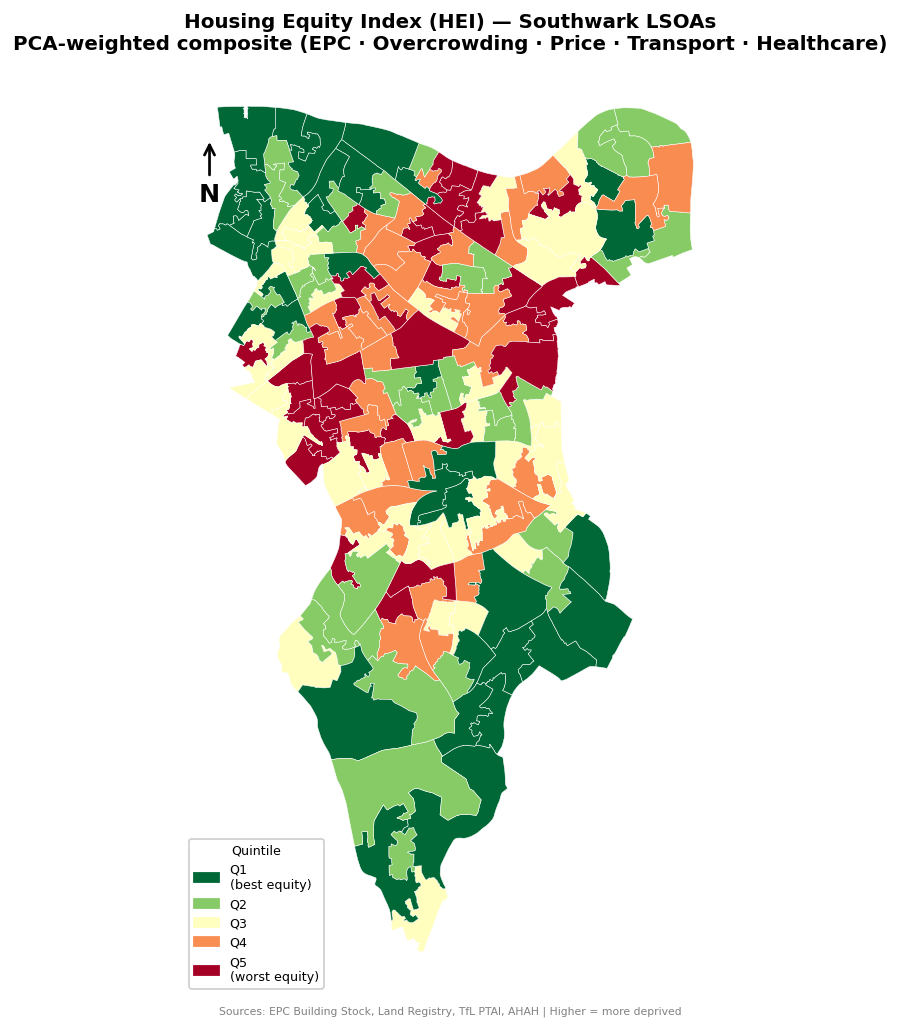

Saved → map_HEI_southwark.png


In [20]:
fig, ax = plt.subplots(figsize=(8, 8))

choropleth_quintile(
    ax, geo, 'HEI_bayes',
    title='Housing Equity Index (HEI) — Southwark LSOAs\n'
          'PCA-weighted composite (EPC · Overcrowding · Price · Transport · Healthcare)',
    legend_labels=QUINTILE_LABELS_HEI,
    source_note='Sources: EPC Building Stock, Land Registry, TfL PTAI, AHAH | Higher = more deprived'
)

plt.tight_layout()
plt.savefig(os.path.join(DATA, 'map_HEI_southwark.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved → map_HEI_southwark.png')

In [21]:
# HEI descriptive statistics by quintile
hei_stats = (
    geo.groupby('HEI_quintile', observed=True)
    [['HEI_bayes','avg_epc_rating_num','overcrowding_proxy',
      'median_house_price','transport_ptai','hospital']]
    .agg(['mean','std'])
    .round(3)
)
print('=== HEI Quintile Statistics ===')
hei_stats

=== HEI Quintile Statistics ===


HEI_pca       avg_epc_rating_num       overcrowding_proxy        \
                mean   std               mean   std               mean   std   
HEI_quintile                                                                   
Q1 (best)      0.157 0.093              4.438 0.208              0.003 0.001   
Q2             0.355 0.038              4.483 0.253              0.004 0.001   
Q3             0.456 0.024              4.486 0.225              0.004 0.001   
Q4             0.535 0.021              4.506 0.208              0.004 0.001   
Q5 (worst)     0.657 0.092              4.492 0.165              0.004 0.001   

             median_house_price            transport_ptai        hospital  \
                           mean        std           mean    std     mean   
HEI_quintile                                                                
Q1 (best)            685310.667 304490.110         42.866 35.409    1.787   
Q2                   547320.086 242731.142         24.181 21.835    1.635   
Q3                   488424.242 165003.001         24.422 17.593    1.237   
Q4                   498590.677 152449.946         14.863  5.575    1.171   
Q5 (worst)           446757.258 141697.488         16.949  6.418    0.961   

                    
               std  
HEI_quintile        
Q1 (best)    0.892  
Q2           0.482  
Q3           0.346  
Q4           0.292  
Q5 (worst)   0.295

In [22]:
# Top 10 most and least deprived LSOAs
cols_show = ['lsoa21nm','HEI_bayes','HEI_quintile']
print('Top 10 most deprived (HEI_bayes highest):')
print(geo.nlargest(10, 'HEI_bayes')[cols_show].to_string(index=False))
print('\nTop 10 best equity (HEI_bayes lowest):')
print(geo.nsmallest(10, 'HEI_bayes')[cols_show].to_string(index=False))

Top 10 most deprived (HEI_pca highest):
      lsoa21nm  HEI_pca HEI_quintile
Southwark 018B    0.999   Q5 (worst)
Southwark 021E    0.912   Q5 (worst)
Southwark 004G    0.748   Q5 (worst)
Southwark 004I    0.748   Q5 (worst)
Southwark 019A    0.734   Q5 (worst)
Southwark 010B    0.731   Q5 (worst)
Southwark 020D    0.719   Q5 (worst)
Southwark 021C    0.687   Q5 (worst)
Southwark 004E    0.674   Q5 (worst)
Southwark 014A    0.672   Q5 (worst)

Top 10 best equity (HEI_pca lowest):
      lsoa21nm  HEI_pca HEI_quintile
Southwark 034A    0.001    Q1 (best)
Southwark 029A    0.006    Q1 (best)
Southwark 002B    0.015    Q1 (best)
Southwark 034E    0.024    Q1 (best)
Southwark 002C    0.028    Q1 (best)
Southwark 029C    0.050    Q1 (best)
Southwark 029B    0.056    Q1 (best)
Southwark 002D    0.074    Q1 (best)
Southwark 034D    0.076    Q1 (best)
Southwark 033A    0.091    Q1 (best)


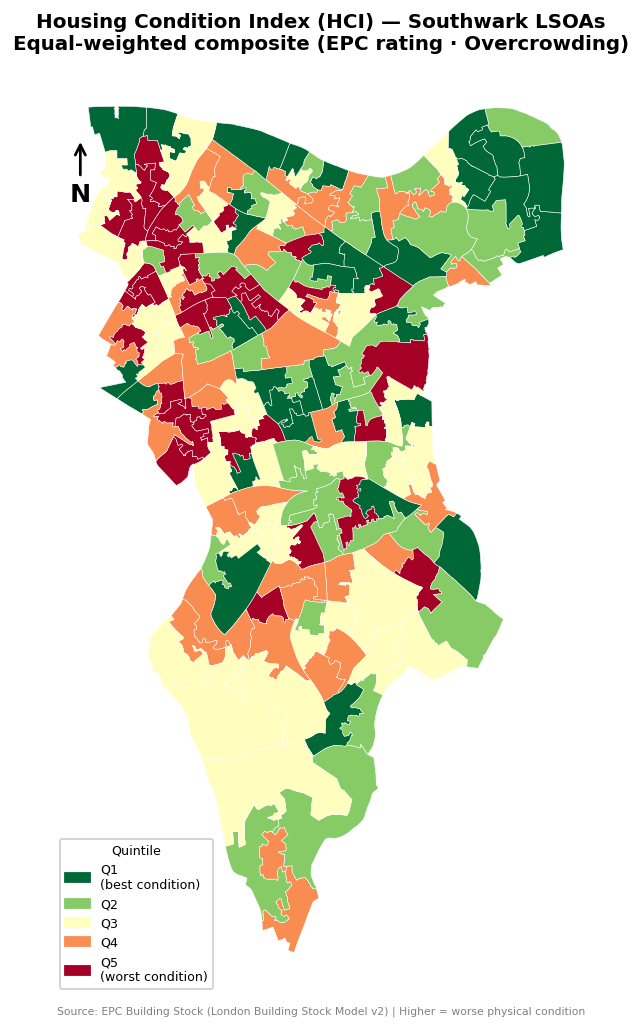

Saved → map_HCI_southwark.png


In [23]:
fig, ax = plt.subplots(figsize=(8, 8))

choropleth_quintile(
    ax, geo, 'HCI',
    title='Housing Condition Index (HCI) — Southwark LSOAs\n'
          'Equal-weighted composite (EPC rating · Overcrowding)',
    legend_labels=QUINTILE_LABELS_HCI,
    source_note='Source: EPC Building Stock (London Building Stock Model v2) | Higher = worse physical condition'
)

plt.tight_layout()
plt.savefig(os.path.join(DATA, 'map_HCI_southwark.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved → map_HCI_southwark.png')

In [24]:
# HCI component breakdown by quintile
hci_stats = (
    geo.groupby('HCI_quintile', observed=True)
    [['HCI','avg_epc_rating_num','overcrowding_proxy','avg_floor_area','avg_rooms']]
    .mean()
    .round(3)
)
# Translate avg_epc_rating_num back to letter grade for readability
epc_grade = {7:'A',6:'B',5:'C',4:'D',3:'E',2:'F',1:'G'}
hci_stats['approx_epc_grade'] = hci_stats['avg_epc_rating_num'].round().astype(int).map(epc_grade)
print('=== HCI Quintile Breakdown ===')
hci_stats

=== HCI Quintile Breakdown ===


,HCI,avg_epc_rating_num,overcrowding_proxy,avg_floor_area,avg_rooms,approx_epc_grade
HCI_quintile,,,,,,
Q1 (best condition),0.377,4.657,0.004,76.450,3.730,C
Q2,0.452,4.525,0.004,77.279,3.718,C
Q3,0.490,4.402,0.003,85.326,3.815,D
Q4,0.529,4.392,0.004,78.520,3.669,D
Q5 (worst condition),0.615,4.428,0.005,65.045,3.433,D


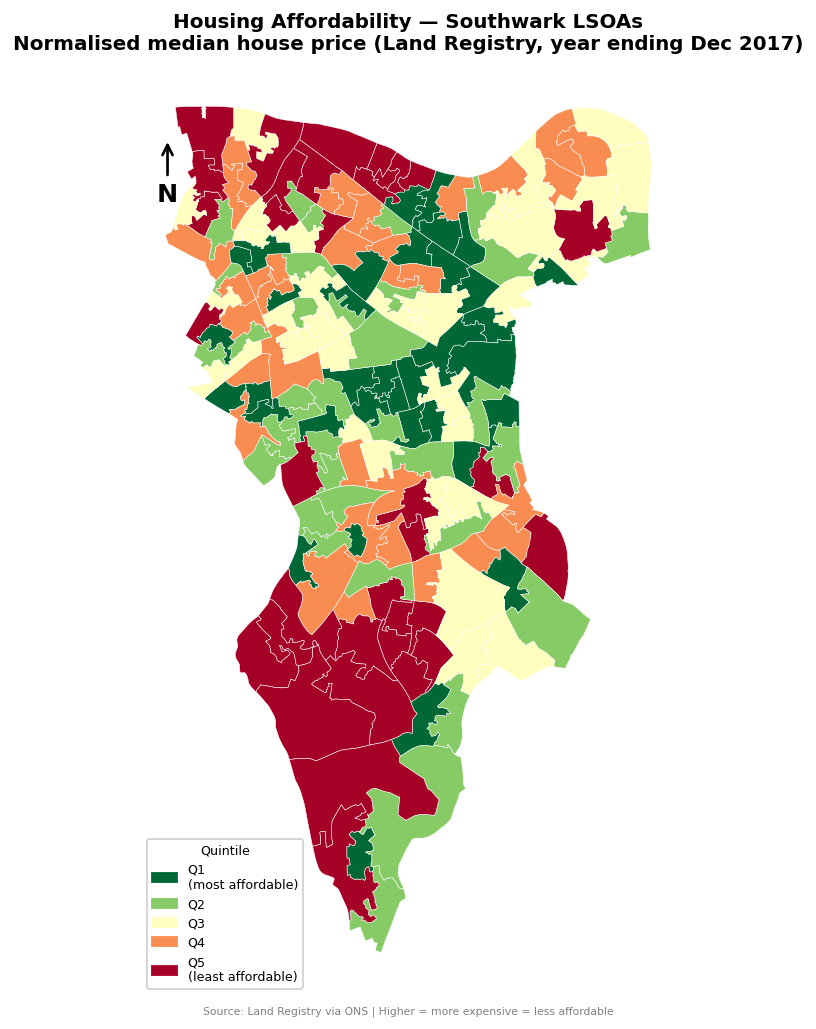

Saved → map_Affordability_southwark.png


In [25]:
fig, ax = plt.subplots(figsize=(8, 8))

choropleth_quintile(
    ax, geo, 'Affordability',
    title='Housing Affordability — Southwark LSOAs\n'
          'Normalised median house price (Land Registry, year ending Dec 2017)',
    legend_labels=QUINTILE_LABELS_AFF,
    source_note='Source: Land Registry via ONS | Higher = more expensive = less affordable'
)

plt.tight_layout()
plt.savefig(os.path.join(DATA, 'map_Affordability_southwark.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved → map_Affordability_southwark.png')

In [26]:
# Affordability statistics by quintile
aff_stats = (
    geo.groupby('Aff_quintile', observed=True)
    [['median_house_price','Affordability']]
    .agg(['mean','min','max'])
    .round(0)
)
print('=== Affordability Quintile Statistics (£) ===')
aff_stats

=== Affordability Quintile Statistics (£) ===


median_house_price                        Affordability  \
                                    mean        min         max          mean   
Aff_quintile                                                                    
Q1 (most affordable)          331766.000 236500.000  370000.000         0.000   
Q2                            424738.000 375000.000  460000.000         0.000   
Q3                            488125.000 465500.000  510000.000         0.000   
Q4                            553173.000 512250.000  620000.000         0.000   
Q5 (least affordable)         862706.000 623000.000 1675000.000         1.000   

                                   
                        min   max  
Aff_quintile                       
Q1 (most affordable)  0.000 0.000  
Q2                    0.000 0.000  
Q3                    0.000 0.000  
Q4                    0.000 0.000  
Q5 (least affordable) 0.000 1.000

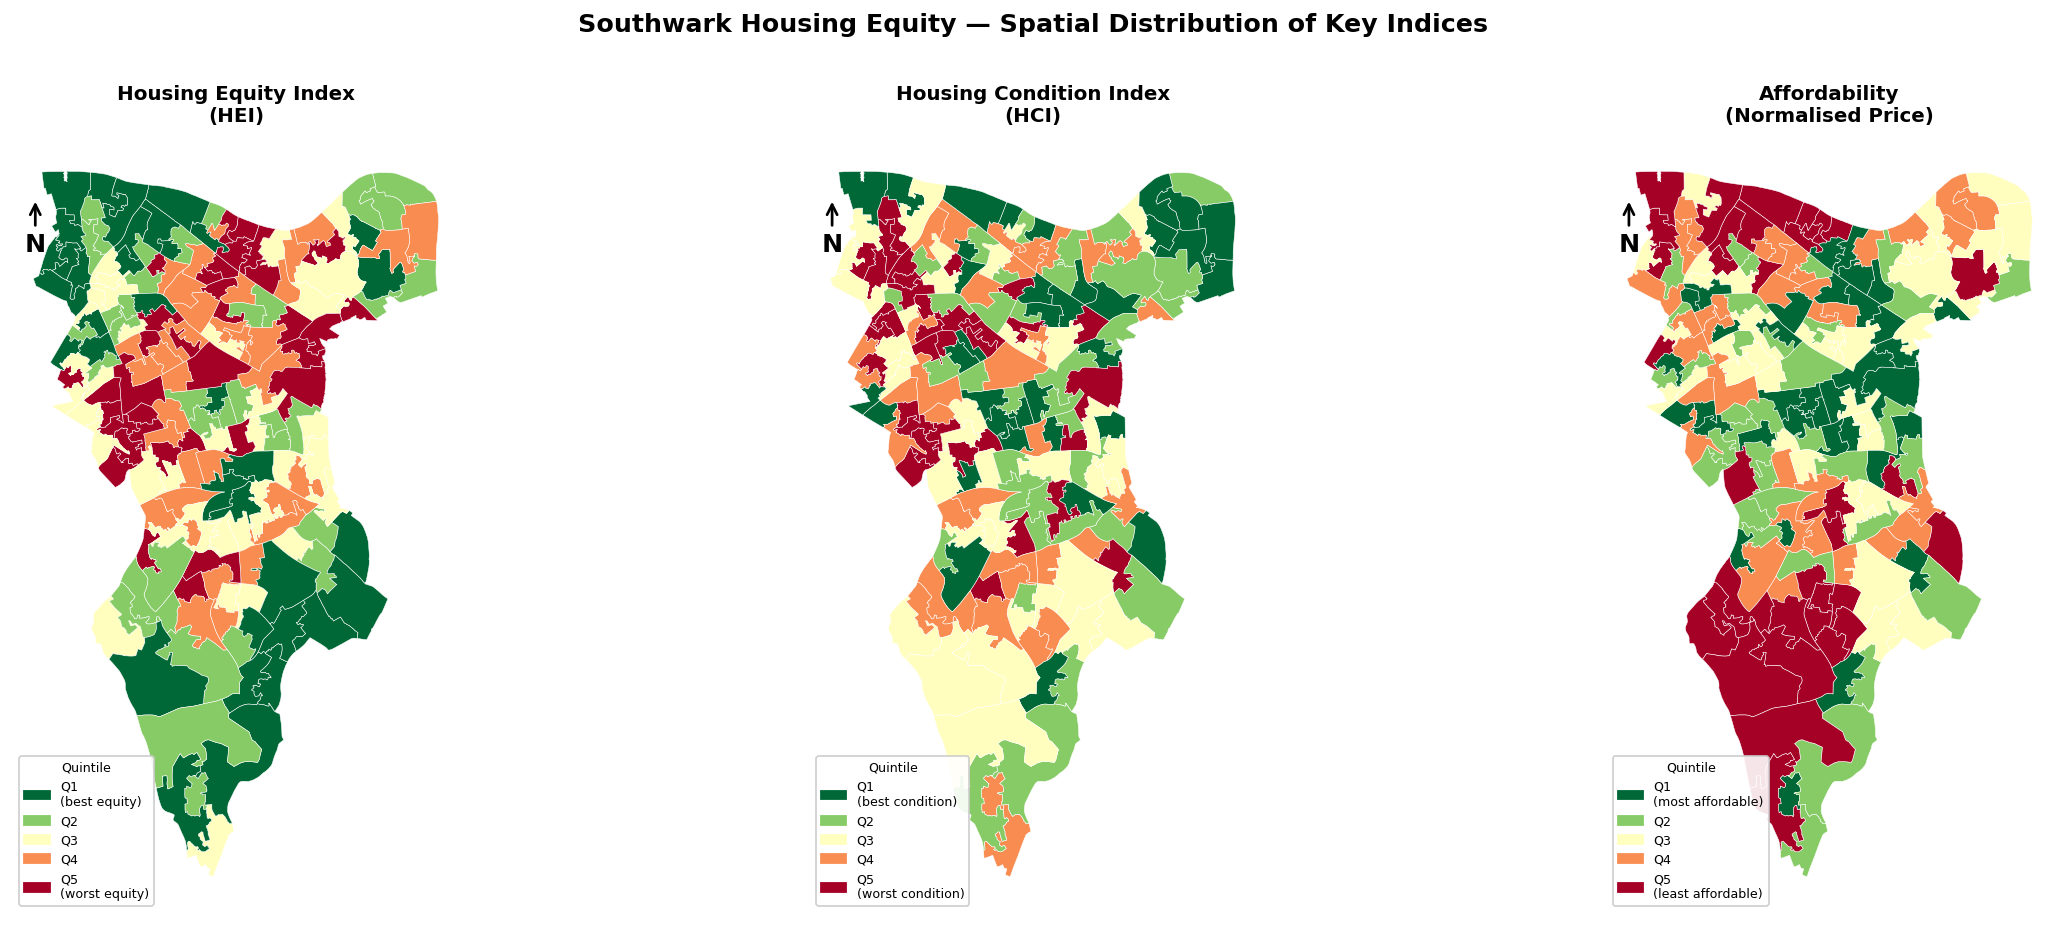

Saved → map_comparison_southwark.png


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

maps = [
    ('HEI_bayes',       'Housing Equity Index\n(HEI)',         QUINTILE_LABELS_HEI),
    ('HCI',           'Housing Condition Index\n(HCI)',      QUINTILE_LABELS_HCI),
    ('Affordability', 'Affordability\n(Normalised Price)',   QUINTILE_LABELS_AFF),
]

for ax, (col, title, labels) in zip(axes, maps):
    choropleth_quintile(ax, geo, col, title=title, legend_labels=labels)

fig.suptitle('Southwark Housing Equity — Spatial Distribution of Key Indices',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DATA, 'map_comparison_southwark.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved → map_comparison_southwark.png')

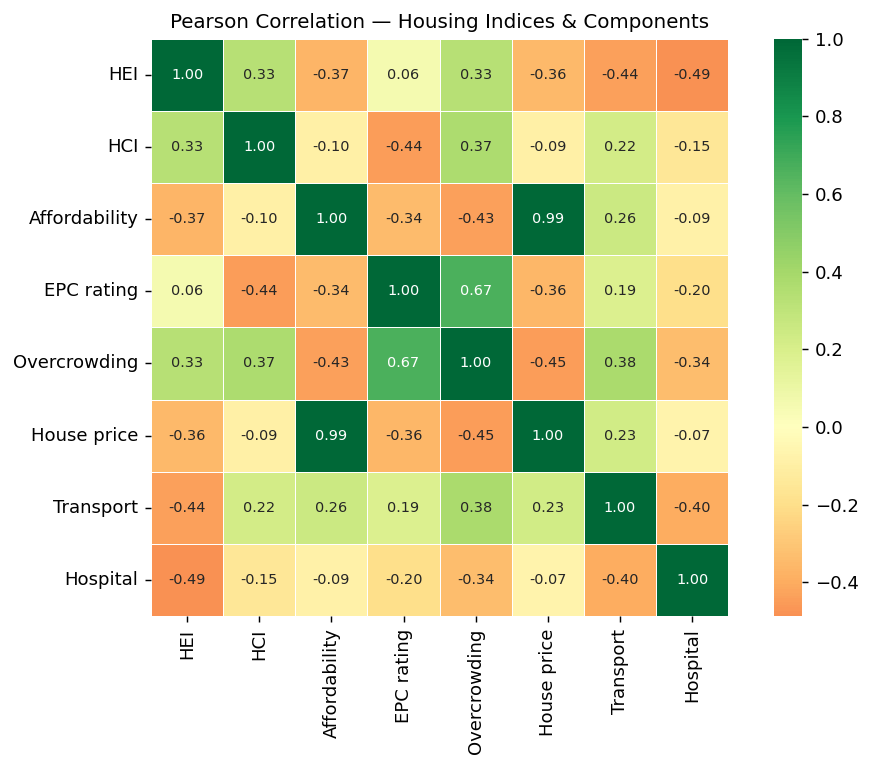

In [28]:
# Correlation matrix: HEI, HCI, Affordability + component variables
corr_vars = ['HEI_bayes','HCI','Affordability',
             'avg_epc_rating_num','overcrowding_proxy',
             'median_house_price','transport_ptai','hospital']
corr_labels = ['HEI','HCI','Affordability',
                'EPC rating','Overcrowding','House price','Transport','Hospital']

corr_mat = geo[corr_vars].corr()
corr_mat.index   = corr_labels
corr_mat.columns = corr_labels

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Pearson Correlation — Housing Indices & Components', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(DATA, 'corr_hei_hci_aff.png'), dpi=150, bbox_inches='tight')
plt.show()

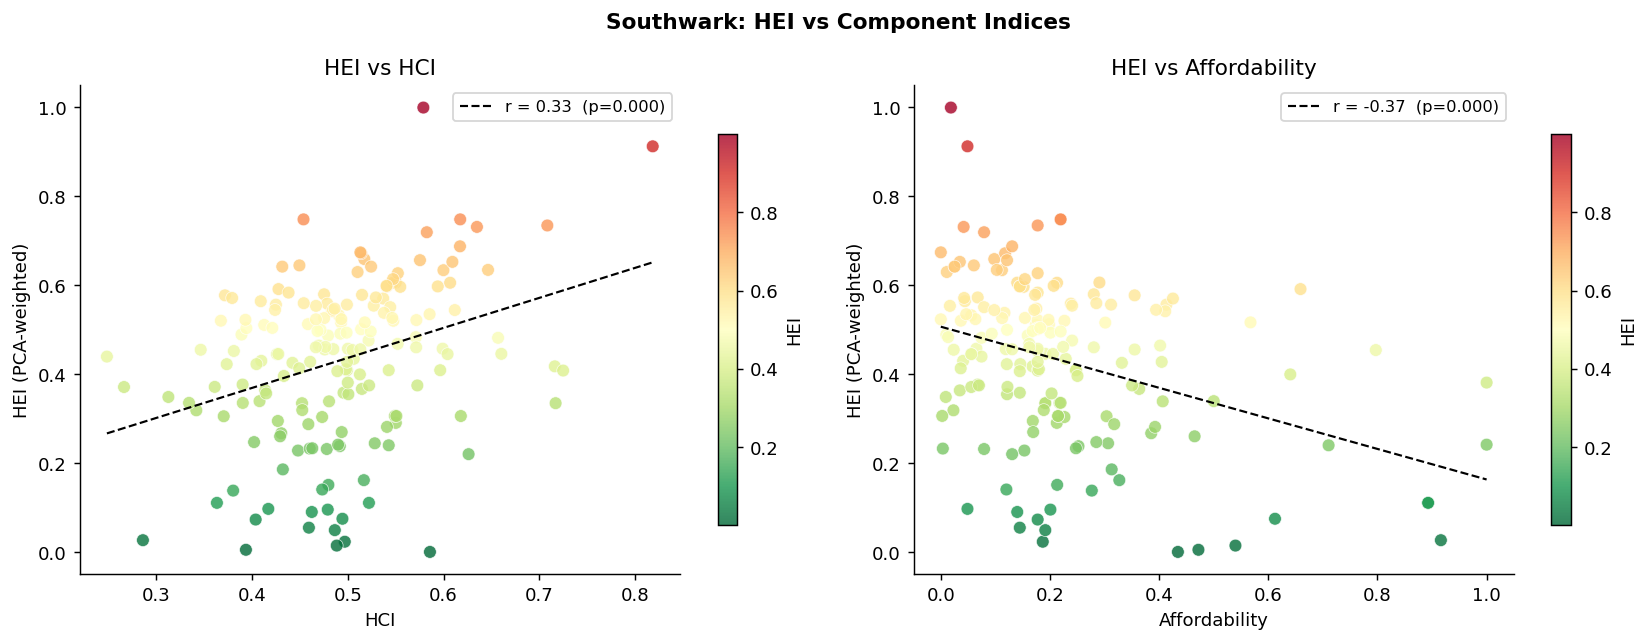

In [29]:
# Scatter: HEI vs HCI vs Affordability — coloured by HEI quintile
palette = {'Q1 (best)':'#1a9641','Q2':'#a6d96a','Q3':'#ffffbf',
           'Q4':'#fdae61','Q5 (worst)':'#d7191c'}

# Standardise quintile label for colour mapping
geo['HEI_q_short'] = geo['HEI_quintile'].astype(str).str.replace(
    r' \(.*?\)', '', regex=True
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (xcol, xlabel) in zip(axes, [('HCI','HCI'), ('Affordability','Affordability')]):
    plot_df = geo.dropna(subset=['HEI_bayes', xcol])
    sc = ax.scatter(plot_df[xcol], plot_df['HEI_bayes'],
                    c=plot_df['HEI_bayes'], cmap='RdYlGn_r', s=50, alpha=0.8, edgecolors='white', lw=0.4)
    # Regression line
    m, b, r, p, _ = stats.linregress(plot_df[xcol], plot_df['HEI_bayes'])
    xr = np.linspace(plot_df[xcol].min(), plot_df[xcol].max(), 100)
    ax.plot(xr, m * xr + b, 'k--', lw=1.2, label=f'r = {r:.2f}  (p={p:.3f})')
    ax.set(xlabel=xlabel, ylabel='HEI (PCA-weighted)', title=f'HEI vs {xlabel}')
    ax.legend(fontsize=9)
    plt.colorbar(sc, ax=ax, label='HEI', shrink=0.8)

plt.suptitle('Southwark: HEI vs Component Indices', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA, 'scatter_hei_vs_hci_aff.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Spatial Inequality Summary Statistics

In [30]:
def gini(arr):
    """Compute Gini coefficient for a 1-D array."""
    arr = np.sort(arr[~np.isnan(arr)])
    n   = len(arr)
    idx = np.arange(1, n + 1)
    return (2 * np.sum(idx * arr) - (n + 1) * np.sum(arr)) / (n * np.sum(arr))

summary_rows = []
for col, label in [('HEI_bayes','HEI'),('HCI','HCI'),('Affordability','Affordability'),
                    ('median_house_price','House Price (£)')]:
    v = geo[col].dropna().values
    summary_rows.append({
        'Index'  : label,
        'Mean'   : np.mean(v),
        'Std'    : np.std(v),
        'Min'    : np.min(v),
        'Max'    : np.max(v),
        'Gini'   : gini(v),
        'IQR'    : np.percentile(v, 75) - np.percentile(v, 25),
    })

summary = pd.DataFrame(summary_rows).set_index('Index').round(4)
print('=== Southwark Housing Inequality Summary ===')
summary

=== Southwark Housing Inequality Summary ===


,Mean,Std,Min,Max,Gini,IQR
Index,,,,,,
HEI,0.432,0.179,0.001,0.999,0.230,0.216
HCI,0.493,0.087,0.248,0.818,0.096,0.109
Affordability,0.219,0.191,0.000,1.000,0.427,0.150
House Price (£),534940.129,224917.850,236500.000,1675000.000,0.201,197500.000


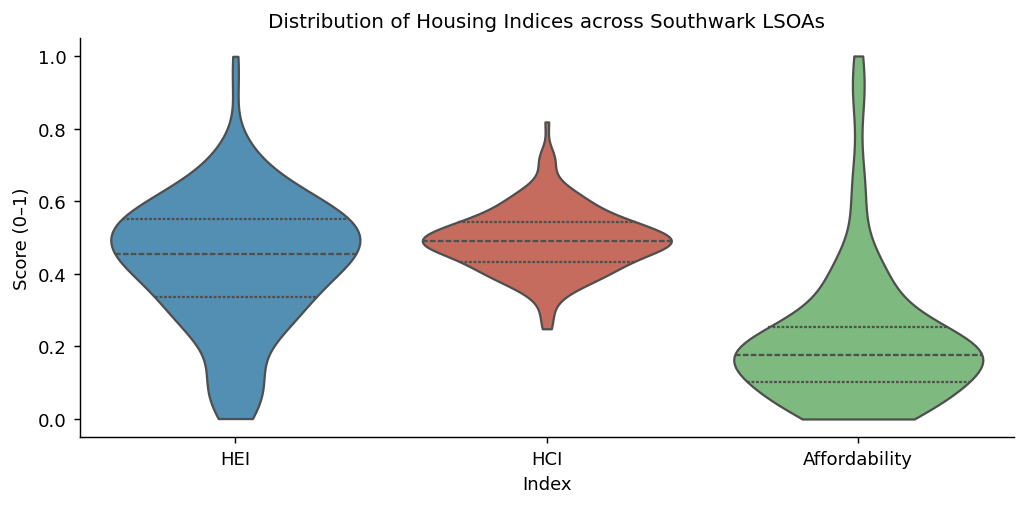

In [31]:
# Distribution comparison — violin plots for all three indices
plot_df = pd.DataFrame({
    'HEI'           : geo['HEI_bayes'],
    'HCI'           : geo['HCI'],
    'Affordability' : geo['Affordability'],
}).melt(var_name='Index', value_name='Score (0–1)')

fig, ax = plt.subplots(figsize=(8, 4))
sns.violinplot(data=plot_df, x='Index', y='Score (0–1)',
               palette=['#4393c3','#d6604d','#74c476'],
               inner='quartile', cut=0, ax=ax)
ax.set_title('Distribution of Housing Indices across Southwark LSOAs', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(DATA, 'violin_indices_southwark.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Save Updated GeoDataFrame

In [32]:
# Save as CSV (drop geometry for portability)
save_cols = ['lsoa21cd','lsoa21nm','HEI_bayes','HEI_quintile',
             'HCI','HCI_quintile','Affordability','Aff_quintile',
             'median_house_price','transport_ptai','hospital',
             'avg_epc_rating_num','overcrowding_proxy']

out = geo[save_cols].copy()
out.to_csv(os.path.join(DATA, 'southwark_indices.csv'), index=False)
print('Saved → southwark_indices.csv')
print(f'Shape : {out.shape}')

Saved → southwark_indices.csv
Shape : (173, 13)
